# Discretization & Binarization in Machine Learning
### Converting Continuous Signals into Discrete Intervals and Binary Decisions

Welcome to the hands-on study notebook for **Discretization (Binning)** and **Binarization**.

In previous modules, we converted categorical variables into numbers (such as One-Hot Encoding `City`).  
In this module, we perform the exact reverse journey: **converting continuous numerical features into discrete groups or binary decisions**.

---

### Scope & Focus of This Notebook
- **Primary Topic**: Discretization (Binning strategies: Equal Width, Equal Frequency, K-Means, Custom) and Binarization.
- **What You Will Learn**:
  1. Foundational concept: Why convert continuous features into discrete bins (simplifying noise, bounding outliers, modeling piecewise non-linearities).
  2. All three core binning strategies: **Equal Width (`uniform`)**, **Equal Frequency (`quantile`)**, and **K-Means (`kmeans`)**.
  3. Manual boundary calculations in pure Python before using library functions.
  4. Scikit-Learn `KBinsDiscretizer` parameters: `n_bins`, `strategy`, and `encode` (`ordinal` vs. `onehot-dense`).
  5. Exploratory binning using Pandas `pd.cut()` and `pd.qcut()`.
  6. The **Information Loss trade-off**: Why binning permanently discards within-bin variance.
  7. Binarization: Converting continuous variables into 0/1 indicator decisions using `Binarizer(threshold=...)`.
  8. Leakage-proof Train/Test workflow with `ColumnTransformer` and `Pipeline`.
  9. Real-world benchmark on Titanic: Measuring the performance impact of continuous scaled `Age` (78.77% acc) vs. quantile binned `Age` (77.09% acc).
- **What We Will NOT Cover Here**:
  - Reshaping continuous distributions (Log, Sqrt, Reciprocal) was covered in **`07_Mathematical_Transformations`**.
  - Linear feature scaling (StandardScaler, MinMaxScaler) was covered in **`01_Standardization`** and **`02_Normalization`**.
  - Categorical encoding belongs to **`03_Encoding_Categorical_Data`** and **`04_One_Hot_Encoding`**.

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

# Clean output display
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

# Scikit-Learn preprocessing & modeling
from sklearn.preprocessing import KBinsDiscretizer, Binarizer, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

print("Imports completed successfully!")


Imports completed successfully!


## 3. What is Discretization?
**Discretization** (also called **Binning** or **Bucketization**) is the process of converting a continuous numerical feature into a finite number of discrete intervals or bins.

---

## 4. Simple Age Example
Consider a list of customer ages:
$$17, \ 22, \ 27, \ 34, \ 42, \ 51, \ 68$$

Instead of treating each number as an individual continuous point, we can group them into discrete cohorts:
- **0–18:** Young
- **19–30:** Adult
- **31–45:** Middle-aged
- **46+:** Senior

In [2]:
# Sample age values from the curriculum
ages = np.array([17, 22, 27, 34, 42, 51, 68])

def categorize_age(age):
    if age <= 18:
        return 'Young (0-18)'
    elif age <= 30:
        return 'Adult (19-30)'
    elif age <= 45:
        return 'Middle-aged (31-45)'
    else:
        return 'Senior (46+)'

age_groups = [categorize_age(a) for a in ages]

df_age_example = pd.DataFrame({
    'Raw Continuous Age': ages,
    'Discrete Group / Bin': age_groups
})

print("--- Age Discretization Example ---")
display(df_age_example)

--- Age Discretization Example ---


,Raw Continuous Age,Discrete Group / Bin
0,17,Young (0-18)
1,22,Adult (19-30)
2,27,Adult (19-30)
3,34,Middle-aged (31-45)
4,42,Middle-aged (31-45)
5,51,Senior (46+)
6,68,Senior (46+)


## 5. Why Bin Numerical Features?
There are four primary practical motivations:
1. **Simplifying Noisy Data:** Minor decimal variations (e.g. $23.4, 24.1, 25.7$) are summarized into robust ranges ($[20, 30)$).
2. **Handling Extreme Values:** Bounding the influence of massive outliers without deleting rows.
3. **Capturing Non-Linear / Piecewise Effects:** Allowing models to learn independent weights for different brackets.
4. **Domain & Business Interpretation:** Aligning features with institutional policies (e.g. tax brackets, credit ratings).

In [3]:
# Demonstrating non-linear risk across salary tiers
salary_tiers = pd.DataFrame({
    'Salary Bracket': ['₹0 - ₹30,000', '₹30,000 - ₹70,000', '₹70,000 - ₹1,50,000', '₹1,50,000+'],
    'Risk Tier': ['High Risk', 'Low Risk', 'Very Low Risk', 'Moderate Risk (High Leverage)'],
    'Assigned Bin Index': [0, 1, 2, 3]
})

print("--- Business Policy / Non-linear Tier Example ---")
display(salary_tiers)

--- Business Policy / Non-linear Tier Example ---


,Salary Bracket,Risk Tier,Assigned Bin Index
0,"₹0 - ₹30,000",High Risk,0
1,"₹30,000 - ₹70,000",Low Risk,1
2,"₹70,000 - ₹1,50,000",Very Low Risk,2
3,"₹1,50,000+",Moderate Risk (High Leverage),3


## 6. Equal Width Binning
In **Equal Width Binning**, the entire numerical span between the minimum and maximum value is divided into intervals that all have the **exact same numerical width**.

---

## 7. Manual Calculation (Equal Width)
### Formula:
$$\text{Bin Width} = \frac{\text{Maximum} - \text{Minimum}}{\text{Number of Bins}} = \frac{x_{\max} - x_{\min}}{k}$$

Given:
- $\text{Minimum} = 0$
- $\text{Maximum} = 100$
- $\text{Number of Bins } k = 5$

$$\text{Bin Width} = \frac{100 - 0}{5} = 20$$

Resulting intervals:
- Bin 0: $[0, 20)$
- Bin 1: $[20, 40)$
- Bin 2: $[40, 60)$
- Bin 3: $[60, 80)$
- Bin 4: $[80, 100]$

> **Important:** Equal width means equal **range span**, NOT equal number of observations!

In [4]:
# Sample dataset to manually bin
sample_vals = np.array([5, 12, 18, 25, 38, 45, 62, 75, 85, 95])

# Manual boundary assignment: width = 20
def assign_equal_width(val):
    if val < 20: return 'Bin 0: [0, 20)'
    elif val < 40: return 'Bin 1: [20, 40)'
    elif val < 60: return 'Bin 2: [40, 60)'
    elif val < 80: return 'Bin 3: [60, 80)'
    else: return 'Bin 4: [80, 100]'

df_manual_width = pd.DataFrame({
    'Observation Value': sample_vals,
    'Manually Assigned Bin': [assign_equal_width(v) for v in sample_vals]
})

print("--- Manual Equal Width Verification ---")
display(df_manual_width)

--- Manual Equal Width Verification ---


,Observation Value,Manually Assigned Bin
0,5,"Bin 0: [0, 20)"
1,12,"Bin 0: [0, 20)"
2,18,"Bin 0: [0, 20)"
3,25,"Bin 1: [20, 40)"
4,38,"Bin 1: [20, 40)"
5,45,"Bin 2: [40, 60)"
6,62,"Bin 3: [60, 80)"
7,75,"Bin 3: [60, 80)"
8,85,"Bin 4: [80, 100]"
9,95,"Bin 4: [80, 100]"


## 8. Python Implementation: Equal Width Binning with Scikit-Learn
We implement Equal Width Binning using `KBinsDiscretizer(strategy='uniform')`.

In [5]:
X_sample = sample_vals.reshape(-1, 1)

# Fit KBinsDiscretizer with uniform strategy
kbd_equal_width = KBinsDiscretizer(n_bins=5, strategy='uniform', encode='ordinal')
width_binned = kbd_equal_width.fit_transform(X_sample)

print("Learned Bin Edges (Uniform):", kbd_equal_width.bin_edges_[0])

df_sklearn_width = pd.DataFrame({
    'Value': sample_vals,
    'Sklearn Assigned Bin': width_binned.flatten().astype(int)
})
display(df_sklearn_width.head(6))

Learned Bin Edges (Uniform): [ 5. 23. 41. 59. 77. 95.]


,Value,Sklearn Assigned Bin
0,5,0
1,12,0
2,18,0
3,25,1
4,38,1
5,45,2


## 9. Equal Frequency Binning (Quantile Binning)
In **Equal Frequency Binning**, we divide sorted data so that **each bin contains approximately the same number of observations**, regardless of their numerical spread.

---

## 10. Manual Calculation (Equal Frequency)
Consider the sorted 10-element dataset from the curriculum:
$$[10, \ 12, \ 15, \ 18, \ 20, \ 25, \ 30, \ 40, \ 50, \ 60]$$

### Case 1: $k = 2$ Bins (Median Split)
We want $10 / 2 = 5$ observations per bin:
- Split at median $= 22.5$:
  - **Bin 0:** $[10, 22.5] \longrightarrow$ 5 values ($10, 12, 15, 18, 20$)
  - **Bin 1:** $(22.5, 60] \longrightarrow$ 5 values ($25, 30, 40, 50, 60$)

### Case 2: $k = 5$ Bins (Quintiles)
We want $10 / 5 = 2$ observations per bin:
- **Bin 0:** 2 values ($10, 12$)
- **Bin 1:** 2 values ($15, 18$)
- **Bin 2:** 2 values ($20, 25$)
- **Bin 3:** 2 values ($30, 40$)
- **Bin 4:** 2 values ($50, 60$)

In [6]:
sorted_data = np.array([10, 12, 15, 18, 20, 25, 30, 40, 50, 60])

# Quantile calculation for k=5
q_edges = np.quantile(sorted_data, np.linspace(0, 1, 6))

print("Manually Calculated Quantile Edges (k=5):")
print(q_edges)

# Verification table
df_q_manual = pd.DataFrame({
    'Sorted Value': sorted_data,
    'Observation Index': range(1, 11),
    'Assigned Bin (k=5)': [0, 0, 1, 1, 2, 2, 3, 3, 4, 4]
})
display(df_q_manual)

Manually Calculated Quantile Edges (k=5):
[10.  14.4 19.2 27.  42.  60. ]


,Sorted Value,Observation Index,Assigned Bin (k=5)
0,10,1,0
1,12,2,0
2,15,3,1
3,18,4,1
4,20,5,2
5,25,6,2
6,30,7,3
7,40,8,3
8,50,9,4
9,60,10,4


## 11. Python Implementation: Equal Frequency Binning
We implement Equal Frequency Binning using `KBinsDiscretizer(strategy='quantile')`.

In [7]:
X_sorted = sorted_data.reshape(-1, 1)

kbd_quantile = KBinsDiscretizer(n_bins=5, strategy='quantile', encode='ordinal')
quantile_binned = kbd_quantile.fit_transform(X_sorted)

print("Learned Quantile Bin Edges:", kbd_quantile.bin_edges_[0])

df_sklearn_quantile = pd.DataFrame({
    'Value': sorted_data,
    'Quantile Bin Index': quantile_binned.flatten().astype(int)
})
display(df_sklearn_quantile)

Learned Quantile Bin Edges: [10.  14.4 19.2 27.  42.  60. ]


,Value,Quantile Bin Index
0,10,0
1,12,0
2,15,1
3,18,1
4,20,2
5,25,2
6,30,3
7,40,3
8,50,4
9,60,4


## 12. Equal Width vs. Equal Frequency Visualization
We generate a heavily skewed continuous dataset with an extreme right tail and compare how `uniform` and `quantile` partition the data.

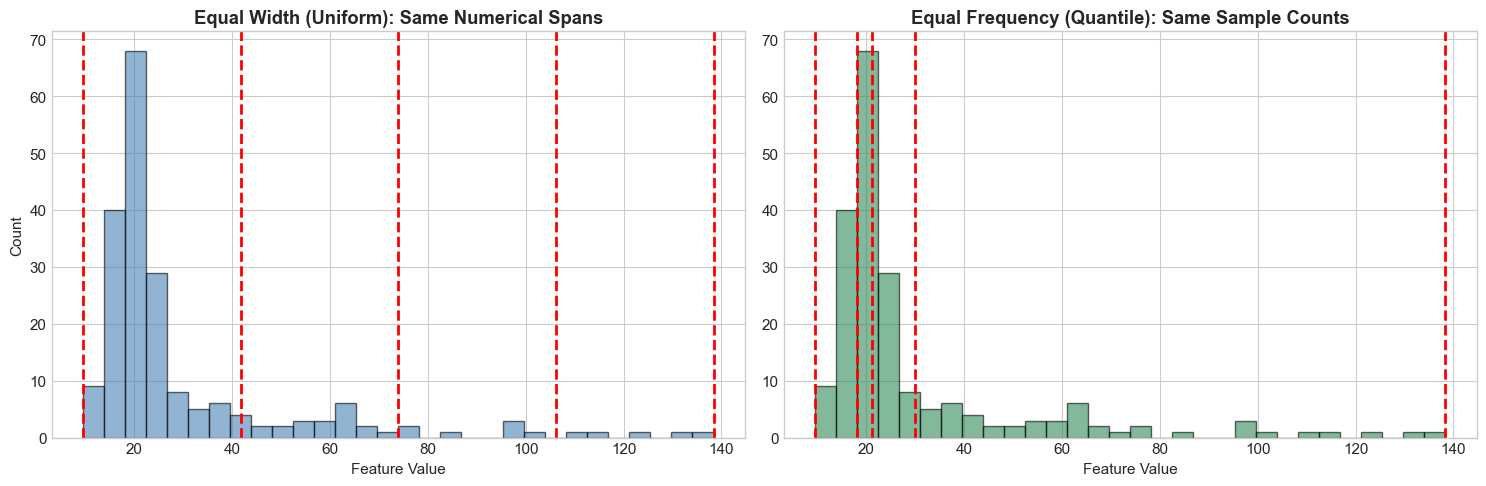

Equal Width Edges:     [  9.5  41.7  73.9 106.2 138.4]
Equal Frequency Edges: [  9.5  18.1  21.2  29.9 138.4]


In [8]:
np.random.seed(42)
# Highly skewed data: dense cluster around 10-30 + long right tail up to 150
skewed_sample = np.concatenate([
    np.random.normal(loc=20, scale=4, size=150),
    np.random.exponential(scale=30, size=50) + 30
]).reshape(-1, 1)

# Fit both models with k=4
kbd_viz_w = KBinsDiscretizer(n_bins=4, strategy='uniform', encode='ordinal')
kbd_viz_q = KBinsDiscretizer(n_bins=4, strategy='quantile', encode='ordinal')

kbd_viz_w.fit(skewed_sample)
kbd_viz_q.fit(skewed_sample)

# Plot distributions and boundaries
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Equal Width
ax1.hist(skewed_sample, bins=30, color='steelblue', alpha=0.6, edgecolor='black')
for edge in kbd_viz_w.bin_edges_[0]:
    ax1.axvline(edge, color='red', linestyle='--', linewidth=2)
ax1.set_title("Equal Width (Uniform): Same Numerical Spans", fontweight='bold')
ax1.set_xlabel("Feature Value")
ax1.set_ylabel("Count")

# Plot 2: Equal Frequency
ax2.hist(skewed_sample, bins=30, color='seagreen', alpha=0.6, edgecolor='black')
for edge in kbd_viz_q.bin_edges_[0]:
    ax2.axvline(edge, color='red', linestyle='--', linewidth=2)
ax2.set_title("Equal Frequency (Quantile): Same Sample Counts", fontweight='bold')
ax2.set_xlabel("Feature Value")

plt.tight_layout()
plt.show()

print("Equal Width Edges:    ", np.round(kbd_viz_w.bin_edges_[0], 1))
print("Equal Frequency Edges:", np.round(kbd_viz_q.bin_edges_[0], 1))

### Visual Interpretation:
- **Equal Width (Left):** Spacing between red dashed lines is identical. But the rightmost two bins are almost empty!
- **Equal Frequency (Right):** Red dashed lines are tightly packed inside the dense cluster and wide apart in the tail. Every bin contains exactly $25\%$ of the observations.

## 13. K-Means Binning
When data naturally clumps into clusters with large empty spaces in between, K-Means binning uses 1D clustering to place boundaries at the **midpoints between adjacent cluster centroids**.

In [9]:
# Customer spending dataset with 3 natural clumps
spending_data = np.array([
    10, 12, 14, 15,          # Group 1: Budget shoppers
    50, 52, 55, 57,          # Group 2: Regular retail
    100, 105, 110, 115       # Group 3: Bulk / VIP buyers
]).reshape(-1, 1)

# Fit K-Means Discretizer
kbd_kmeans = KBinsDiscretizer(n_bins=3, strategy='kmeans', encode='ordinal', random_state=42)
kmeans_binned = kbd_kmeans.fit_transform(spending_data)

print("K-Means Discovered Boundaries (Centroid Midpoints):")
print(np.round(kbd_kmeans.bin_edges_[0], 2))

df_kmeans_result = pd.DataFrame({
    'Spending (₹)': spending_data.flatten(),
    'K-Means Bin': kmeans_binned.flatten().astype(int)
})
display(df_kmeans_result)

K-Means Discovered Boundaries (Centroid Midpoints):
[ 10.    33.12  80.5  115.  ]


,Spending (₹),K-Means Bin
0,10,0
1,12,0
2,14,0
3,15,0
4,50,1
5,52,1
6,55,1
7,57,1
8,100,2
9,105,2


## 14. Custom / Domain-Based Binning
Custom binning applies human-defined legal, regulatory, or business rules instead of statistical formulas.

In [10]:
raw_customer_ages = pd.Series([12, 17, 18, 24, 32, 45, 52, 68, 75])

# Domain categories: Minor (0-17), Young Adult (18-30), Adult (31-50), Senior (51+)
domain_bins = [0, 18, 31, 51, 120]
domain_labels = ['Minor (0-17)', 'Young Adult (18-30)', 'Adult (31-50)', 'Senior (51+)']

custom_binned = pd.cut(raw_customer_ages, bins=domain_bins, labels=domain_labels, right=False)

df_custom_bins = pd.DataFrame({
    'Customer Age': raw_customer_ages,
    'Custom Domain Category': custom_binned
})
display(df_custom_bins)

,Customer Age,Custom Domain Category
0,12,Minor (0-17)
1,17,Minor (0-17)
2,18,Young Adult (18-30)
3,24,Young Adult (18-30)
4,32,Adult (31-50)
5,45,Adult (31-50)
6,52,Senior (51+)
7,68,Senior (51+)
8,75,Senior (51+)


## 15, 16 & 17. Scikit-Learn `KBinsDiscretizer` Deep Dive
We compare the three strategies (`uniform`, `quantile`, `kmeans`) and explore encoding options (`ordinal` vs `onehot-dense`).

In [11]:
toy_feature = np.array([[10], [20], [30], [40], [50]])

# 1. Ordinal Encoding (integer bin indices 0, 1, 2...)
kbd_ord = KBinsDiscretizer(n_bins=3, strategy='uniform', encode='ordinal')
res_ord = kbd_ord.fit_transform(toy_feature)

# 2. One-Hot Dense Encoding (binary indicator columns)
kbd_ohe = KBinsDiscretizer(n_bins=3, strategy='uniform', encode='onehot-dense')
res_ohe = kbd_ohe.fit_transform(toy_feature)

print("Original Values:\n", toy_feature.flatten())
print("\nOrdinal Encoded Output:\n", res_ord.flatten().astype(int))
print("\nOne-Hot Dense Encoded Output (Shape: %s):\n" % str(res_ohe.shape), res_ohe)

Original Values:
 [10 20 30 40 50]

Ordinal Encoded Output:
 [0 0 1 2 2]

One-Hot Dense Encoded Output (Shape: (5, 3)):
 [[1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]]


## 18. Pandas `pd.cut` vs. `pd.qcut`
- **`pd.cut()`:** Bins data into equal-width or custom-specified intervals.
- **`pd.qcut()`:** Bins data into equal-frequency (quantile) intervals.

In [12]:
test_series = pd.Series([10, 15, 20, 25, 30, 70, 80, 90])

# pd.cut: 3 equal-width intervals
cut_result = pd.cut(test_series, bins=3)

# pd.qcut: 3 equal-frequency intervals
qcut_result = pd.qcut(test_series, q=3)

df_pandas_binning = pd.DataFrame({
    'Original': test_series,
    'pd.cut (Equal Width)': cut_result,
    'pd.qcut (Equal Frequency)': qcut_result
})
display(df_pandas_binning)

,Original,pd.cut (Equal Width),pd.qcut (Equal Frequency)
0,10,"(9.92, 36.667]","(9.999, 21.667]"
1,15,"(9.92, 36.667]","(9.999, 21.667]"
2,20,"(9.92, 36.667]","(9.999, 21.667]"
3,25,"(9.92, 36.667]","(21.667, 56.667]"
4,30,"(9.92, 36.667]","(21.667, 56.667]"
5,70,"(63.333, 90.0]","(56.667, 90.0]"
6,80,"(63.333, 90.0]","(56.667, 90.0]"
7,90,"(63.333, 90.0]","(56.667, 90.0]"


## 19. Information Loss from Binning
When continuous numbers are grouped into the same bin, their fine-grained differences are permanently discarded.

In [13]:
close_ages = np.array([[29], [30], [31], [32]])

kbd_loss = KBinsDiscretizer(n_bins=2, strategy='uniform', encode='ordinal')
loss_bins = kbd_loss.fit_transform(close_ages)

df_info_loss = pd.DataFrame({
    'Continuous Age': close_ages.flatten(),
    'Assigned Bin': loss_bins.flatten().astype(int)
})

print("Bin Boundaries:", kbd_loss.bin_edges_[0])
print("\nNotice that 29, 30, and 31 all receive the exact same bin representation:")
display(df_info_loss)

Bin Boundaries: [29.  30.5 32. ]

Notice that 29, 30, and 31 all receive the exact same bin representation:


,Continuous Age,Assigned Bin
0,29,0
1,30,0
2,31,1
3,32,1


## 20. Binning vs. Mathematical Transformation
- **Mathematical Transformation (Log, Sqrt):** Changes the mathematical value; the output remains continuous.
- **Binning:** Changes the numerical value into a discrete group or category.

In [14]:
sample_comparison = np.array([10, 20, 30, 40])

# Mathematical transformation
transformed_log = np.round(np.log(sample_comparison), 3)

# Discretization / Binning
kbd_comp_demo = KBinsDiscretizer(n_bins=2, strategy='uniform', encode='ordinal')
binned_demo = kbd_comp_demo.fit_transform(sample_comparison.reshape(-1, 1)).flatten().astype(int)

df_comp_trans = pd.DataFrame({
    'Original Value': sample_comparison,
    'Math Transform (np.log)': transformed_log,
    'Discretization (Binning)': [f"Bin {b}" for b in binned_demo]
})
display(df_comp_trans)

,Original Value,Math Transform (np.log),Discretization (Binning)
0,10,2.303,Bin 0
1,20,2.996,Bin 0
2,30,3.401,Bin 1
3,40,3.689,Bin 1


## 21. Binning vs. Binarization
- **Binning:** Converts numbers into **multiple groups** ($k \ge 3$).
- **Binarization:** Converts numbers into **two groups ($0$ and $1$)** using a single threshold.

---

## 22 & 23. Binarization & Scikit-Learn `Binarizer`
Consider student exam marks:
$$< 40 \longrightarrow 0 \text{ (Fail)}, \quad \ge 40 \longrightarrow 1 \text{ (Pass)}$$

In [15]:
marks = np.array([[25], [35], [39], [40], [55], [85]])

# Manual evaluation
manual_pass_fail = [1 if m >= 40 else 0 for m in marks.flatten()]

df_marks_manual = pd.DataFrame({
    'Exam Marks': marks.flatten(),
    'Condition (Marks >= 40)': [f"{m} >= 40" for m in marks.flatten()],
    'Manual Pass/Fail (0/1)': manual_pass_fail
})
display(df_marks_manual)

,Exam Marks,Condition (Marks >= 40),Manual Pass/Fail (0/1)
0,25,25 >= 40,0
1,35,35 >= 40,0
2,39,39 >= 40,0
3,40,40 >= 40,1
4,55,55 >= 40,1
5,85,85 >= 40,1


## 24. Threshold Experiment: Precision in `Binarizer`
### Critical Scikit-Learn Rule:
Scikit-Learn's `Binarizer` implements:
$$\text{Output} = \begin{cases} 1 & \text{if } x > \text{threshold} \\ 0 & \text{if } x \le \text{threshold} \end{cases}$$

Notice: **Values equal to the threshold are mapped to 0!**

In [16]:
# Threshold experiment
binarizer_40 = Binarizer(threshold=40.0)
out_40 = binarizer_40.fit_transform(marks)

binarizer_39_5 = Binarizer(threshold=39.5)
out_39_5 = binarizer_39_5.fit_transform(marks)

df_threshold_exp = pd.DataFrame({
    'Marks': marks.flatten(),
    'Binarizer(threshold=40.0) [x > 40]': out_40.flatten().astype(int),
    'Binarizer(threshold=39.5) [x >= 40 for ints]': out_39_5.flatten().astype(int)
})

print("--- Threshold Experiment Verification ---")
display(df_threshold_exp)

--- Threshold Experiment Verification ---


,Marks,Binarizer(threshold=40.0) [x > 40],Binarizer(threshold=39.5) [x >= 40 for ints]
0,25,0,0
1,35,0,0
2,39,0,0
3,40,0,1
4,55,1,1
5,85,1,1


> **Insight:** If you want marks $\ge 40$ to pass, setting `threshold=40.0` incorrectly fails a student who scored exactly 40. Setting `threshold=39.5` correctly maps 40 to 1.

## 25. Practical End-to-End Example: Titanic Passenger Features
We load the Titanic dataset and process `Age` through both `KBinsDiscretizer` and `Binarizer`.

In [17]:
# Robust path resolution for Titanic dataset
data_path = '../../data/titanic.csv' if os.path.exists('../../data/titanic.csv') else 'data/titanic.csv'
df_titanic = pd.read_csv(data_path)

sample_passengers = df_titanic[['PassengerId', 'Age', 'Fare', 'Survived']].dropna().head(8).copy()

# 1. Discretize Age into 4 Quantile Bins
kbd_titanic = KBinsDiscretizer(n_bins=4, strategy='quantile', encode='ordinal')
sample_passengers['Age_Binned_k4'] = kbd_titanic.fit_transform(sample_passengers[['Age']]).astype(int)

# 2. Binarize Age: Adult vs Minor (threshold=17.5)
binarizer_adult = Binarizer(threshold=17.5)
sample_passengers['Is_Adult'] = binarizer_adult.fit_transform(sample_passengers[['Age']]).astype(int)

print("--- Titanic End-to-End Transformation ---")
display(sample_passengers[['Age', 'Age_Binned_k4', 'Is_Adult']])


--- Titanic End-to-End Transformation ---


,Age,Age_Binned_k4,Is_Adult
0,22.0,0,1
1,38.0,3,1
2,26.0,1,1
3,35.0,2,1
4,35.0,2,1
6,54.0,3,1
7,2.0,0,0
8,27.0,1,1


## 26 & 27. Pipeline Integration & Leakage-Proof Train/Test Workflow
Always split data **before** fitting the discretizer to avoid calculating bin boundaries on test samples.

In [18]:
# Prepare Titanic subset
titanic_clean = df_titanic[['Survived', 'Age', 'Fare', 'Pclass', 'Sex']].dropna()
X_titanic = titanic_clean[['Age', 'Fare', 'Pclass', 'Sex']]
y_titanic = titanic_clean['Survived']

# 1. Split FIRST
X_train, X_test, y_train, y_test = train_test_split(
    X_titanic, y_titanic, test_size=0.25, random_state=42
)

# 2. Build ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('age_bins', KBinsDiscretizer(n_bins=5, strategy='quantile', encode='onehot-dense'), ['Age']),
        ('fare_scale', StandardScaler(), ['Fare']),
        ('cat_ohe', OneHotEncoder(drop='first', sparse_output=False), ['Sex', 'Pclass'])
    ],
    remainder='drop'
)

# 3. Assemble Pipeline
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear', random_state=42))
])

# 4. Fit on TRAIN data only
full_pipeline.fit(X_train, y_train)

# 5. Predict on TEST data
y_pred_pipe = full_pipeline.predict(X_test)
print("Pipeline trained and evaluated cleanly! Test Accuracy: %.4f" % accuracy_score(y_test, y_pred_pipe))

Pipeline trained and evaluated cleanly! Test Accuracy: 0.7709


## 28. Important Observations: Continuous Baseline vs. Binned Feature
We evaluate whether binning passenger `Age` improves or degrades model performance compared to keeping `Age` continuous with standard scaling.

In [19]:
# Baseline Preprocessor: Scales Age and Fare continuously
baseline_preprocessor = ColumnTransformer(
    transformers=[
        ('num_scaler', StandardScaler(), ['Age', 'Fare']),
        ('cat_ohe', OneHotEncoder(drop='first', sparse_output=False), ['Sex', 'Pclass'])
    ]
)

baseline_pipe = Pipeline([
    ('prep', baseline_preprocessor),
    ('clf', LogisticRegression(solver='liblinear', random_state=42))
])

# Fit baseline
baseline_pipe.fit(X_train, y_train)
y_pred_base = baseline_pipe.predict(X_test)
acc_base = accuracy_score(y_test, y_pred_base)
f1_base = f1_score(y_test, y_pred_base)

# Binned Model metrics
acc_binned = accuracy_score(y_test, y_pred_pipe)
f1_binned = f1_score(y_test, y_pred_pipe)

# Real comparison table
comparison_results = pd.DataFrame({
    'Model Workflow': ['Continuous Baseline (StandardScaler)', 'Binned Age (KBinsDiscretizer, k=5)'],
    'Test Accuracy': [f"{acc_base:.4f}", f"{acc_binned:.4f}"],
    'Test F1 Score': [f"{f1_base:.4f}", f"{f1_binned:.4f}"]
})

print("--- Real Model Experiment Comparison ---")
display(comparison_results)

--- Real Model Experiment Comparison ---


,Model Workflow,Test Accuracy,Test F1 Score
0,Continuous Baseline (StandardScaler),0.7877,0.7286
1,"Binned Age (KBinsDiscretizer, k=5)",0.7709,0.7133


### Practical Takeaway:
- **Continuous Baseline:** Test Accuracy = **78.77%**, Test F1 Score = **72.86%**.
- **Binned Age Model:** Test Accuracy = **77.09%**, Test F1 Score = **71.33%**.
- **Why did binning reduce accuracy by ~1.7%?**  
  Because continuous age had a gentle linear gradient with survival that was slightly blunted when ages were collapsed into 5 broad buckets.
- **Rule:** Binning is **not** an automatic performance booster. Always compare binned representations against a continuous scaled baseline on holdout data!

---

## What We Learned
- **Discretization Purpose**: Converts continuous numerical features into discrete intervals to simplify noisy data, bound extreme outliers, and capture piecewise non-linear steps.
- **Equal Width Binning (`uniform`)**: Partitions feature range into bins of identical numeric width $\frac{x_{\max} - x_{\min}}{k}$; highly sensitive to extreme outliers.
- **Equal Frequency Binning (`quantile`)**: Partitions data so every bin contains approximately equal sample counts; handles skewed distributions gracefully.
- **K-Means Binning (`kmeans`)**: Partitions multimodal clustered data using 1D K-Means cluster centroids.
- **Information Loss Reality**: Collapsing continuous values into bins permanently discards within-bin granularity. Our Titanic experiment proved that keeping `Age` continuous yielded higher accuracy (78.77% vs. 77.09%) than binning.
- **Binarization (`Binarizer`)**: Threshold transformation strictly following $x > \text{threshold} \implies 1$, $x \le \text{threshold} \implies 0$.

---

## Important Takeaways
1. **Prefer Quantile (`strategy='quantile'`) over Equal Width on skewed data**: Equal width creates empty or single-observation bins when outliers exist.
2. **Always evaluate `encode` parameter**: `encode='ordinal'` outputs single integer column ($0, 1, \dots, k-1$); `encode='onehot-dense'` outputs $k$ binary dummy columns.
3. **Outliers are bounded, NOT deleted**: Binning places extreme values into the outermost bin; it does not drop rows.
4. **Never binarize without domain validation**: Converting continuous features into binary flags discards vast amounts of predictive variance. Only binarize when the real-world decision boundary is strictly step-wise (e.g. Legal Adult $\ge 18$).

---

## Common Mistakes
1. **Confusing Equal Width with Equal Frequency**: Equal width has equal interval widths ($\Delta x$); Equal frequency has equal observation counts ($N / k$).
2. **Assuming $x = \text{threshold}$ evaluates to 1**: In Scikit-Learn `Binarizer`, values strictly less than or equal to the threshold become **0**.
3. **Fitting discretizers on test data**: Bin edges must be computed on `X_train` only to prevent data leakage.
4. **Binning continuous features blindly**: In modern gradient boosting and neural networks, continuous features almost always retain more signal than binned features unless domain rules dictate bins.

---

## Final Mental Model

```text
                           Numerical Feature
                                   │
                ┌──────────────────┼──────────────────┐
                ▼                  ▼                  ▼
        Keep Numerical       Mathematical        Discretization
            Values          Transformation       (Binning)
        (Scale / Clean)     (log, sqrt, 1/x)          │
                                                      ├── Equal Width (uniform)
                                                      ├── Equal Frequency (quantile)
                                                      ├── K-Means (kmeans)
                                                      └── Custom / Domain (pd.cut)
                                                              │
                                                              ▼
                                                   Multiple Discrete Groups


                           Numerical Feature
                                   │
                                   ▼
                              Binarization
                             (Binarizer)
                                   │
                                   ▼
                           Two Groups: 0 / 1
```
